Data loaded successfully.
  Groups     : ['MiddleAged_Male', 'MiddleAged_Female', 'Older_Male', 'Older_Female']
  CF cases   : 12

Section 2: Stratification Effect

[Pooled Model Performance]
  Model               : Pooled (no stratification)
  Accuracy            : 0.5639
  Class3_R            : 0.5703
  Class3_F1           : 0.5172
  AUC_macro           : 0.9436
  AUC_class3          : 0.9623

[Stratification Effect Summary]
                     Model  Accuracy  Class3_R  Class3_F1  AUC_macro  AUC_class3
Pooled (no stratification)    0.5639    0.5703     0.5172     0.9436      0.9623
           MiddleAged_Male    0.6193    0.4412     0.4762     0.9740      0.9831
         MiddleAged_Female    0.7516    0.5500     0.4583     0.9642      0.9859
                Older_Male    0.3736    0.5619     0.5488     0.9302      0.9184
              Older_Female    0.4532    0.5825     0.5333     0.9731      0.9802
>>> Saved: ../results/tables/stratification_effect.csv
  Saved: figure_comorbidity_

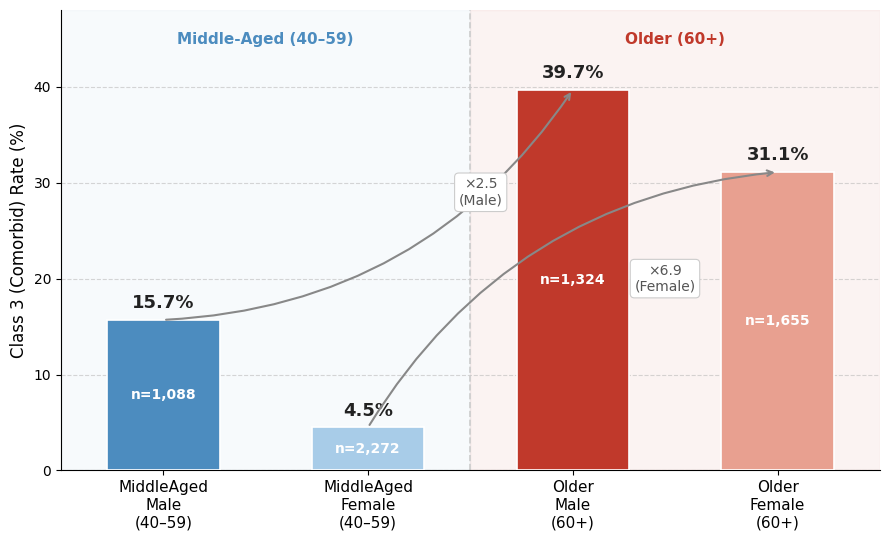


Section 4: Guardrail Range Descriptive Statistics

Guardrail range width by group (mean across 3 cases):
Variable            BMI  Carb_g  Energy_kcal  Sodium_mg  Sugar_g  WaistCirc  Weight
Group                                                                              
MiddleAged_Female  4.03  193.77       441.96     638.20    13.20      13.04    9.30
MiddleAged_Male    3.98  188.85       571.31    1152.46     8.17      14.06   11.84
Older_Female       3.92  180.75       401.43     609.49    10.26      13.66    9.36
Older_Male         3.91  258.80       558.03    1030.58    14.84      13.84   10.82
>>> Saved: ../results/tables/guardrail_descriptive.csv
  Saved: figure_guardrail_heatmap (PNG/PDF/TIFF 600 dpi)


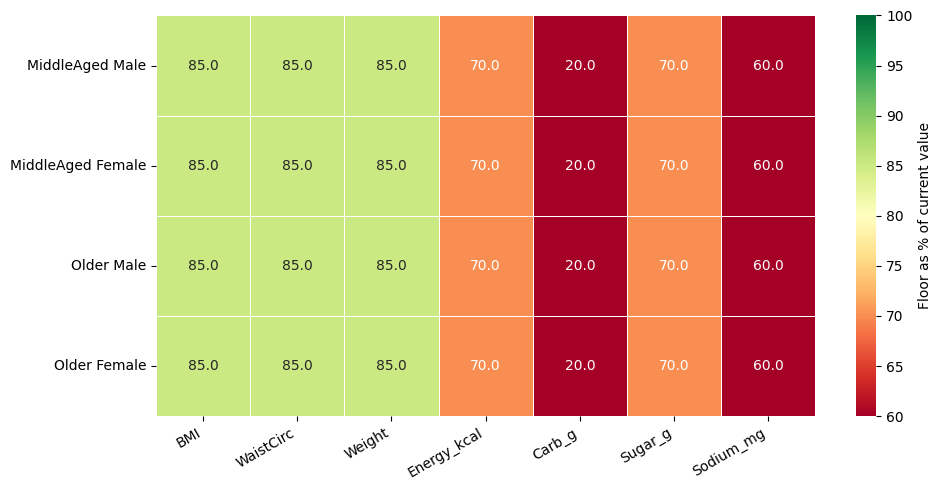


Section 6: CF Pathway Structure Analysis

Average number of changed variables per group:
                    mean   std
Group                         
MiddleAged_Female   9.25  1.54
MiddleAged_Male     8.75  1.82
Older_Female        9.67  0.98
Older_Male         10.55  1.04

Top changed variables per group:
  MiddleAged_Male     : [('Sodium_mg', 12), ('Fat_g', 12), ('Fiber_g', 12)]
  MiddleAged_Female   : [('Sodium_mg', 12), ('Protein_g', 12), ('BMI', 11)]
  Older_Male          : [('BMI', 11), ('WaistCirc', 11), ('Weight', 11)]
  Older_Female        : [('BMI', 12), ('WaistCirc', 12), ('Weight', 12)]
>>> Saved: ../results/tables/cf_pathway_analysis.csv
  Saved: figure_cf_changes (PNG/PDF/TIFF 600 dpi)


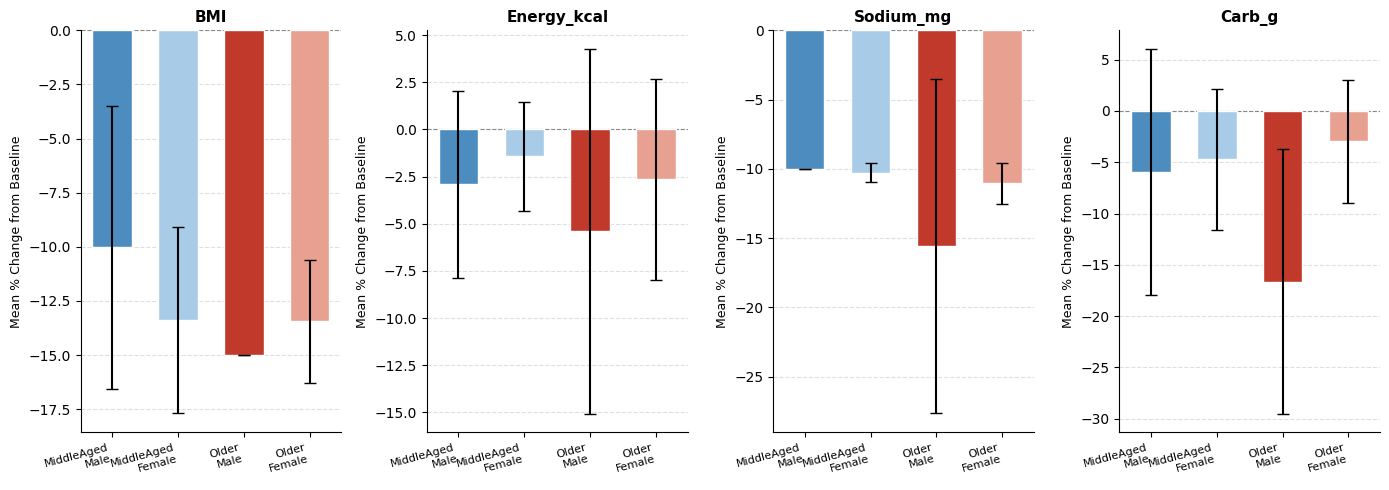

In [1]:
# 05_descriptive_analysis.ipynb
# =============================================================================
# Personalized Health Intervention Pathways for Comorbid Policyholders:
# Loss Ratio Management via LLM Guardrails and Counterfactual Explanations
# -----------------------------------------------------------------------------
# Notebook 05 — Descriptive Analysis & Stratification Effect
#
# Contents:
#   1. Stratification effect: single model vs. 4 stratified models
#   2. Group-level guardrail range descriptive statistics
#   3. CF pathway structure analysis (changed variables, direction, magnitude)
#   4. Key figures for manuscript
#
# Input  : ../results/tables/agent_config.pkl
#          ../results/tables/df_final.pkl
#          ../results/tables/model_{group}.pkl
#          ../results/tables/guardrail_ranges.json
#          ../results/tables/counterfactuals.json
#          ../results/tables/model_performance.csv
# Output : ../results/tables/stratification_effect.csv
#          ../results/tables/guardrail_descriptive.csv
#          ../results/tables/cf_pathway_analysis.csv
#          ../results/figures/figure_comorbidity_rate.{png|pdf|tiff}
#          ../results/figures/figure_guardrail_heatmap.{png|pdf|tiff}
#          ../results/figures/figure_cf_changes.{png|pdf|tiff}
# =============================================================================

# %%
# ## 0. Import Libraries

import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import xgboost as xgb

from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings('ignore')

SAVE_FIG_KWARGS = dict(dpi=600, bbox_inches='tight', facecolor='white')

def save_fig(fig, name: str):
    for ext in ['png', 'pdf', 'tiff']:
        fig.savefig(f'../results/figures/{name}.{ext}',
                    format=ext, **SAVE_FIG_KWARGS)
    print(f"  Saved: {name} (PNG/PDF/TIFF 600 dpi)")

# %%
# ## 1. Load Data and Configuration

agent_config  = joblib.load('../results/tables/agent_config.pkl')
df_final      = joblib.load('../results/tables/df_final.pkl')
perf_df       = pd.read_csv('../results/tables/model_performance.csv')

X_FEATURES      = agent_config['X_features']
TARGET_COL      = agent_config['target_col']
AGEGROUP_CONFIG = agent_config['agegroup_config']

models = {}
for group_name in AGEGROUP_CONFIG:
    try:
        models[group_name] = joblib.load(
            f'../results/tables/model_{group_name}.pkl'
        )
    except FileNotFoundError:
        models[group_name] = None

with open('../results/tables/guardrail_ranges.json', 'r', encoding='utf-8') as f:
    all_guardrails = json.load(f)

with open('../results/tables/counterfactuals.json', 'r', encoding='utf-8') as f:
    cf_data = json.load(f)

print("Data loaded successfully.")
print(f"  Groups     : {list(AGEGROUP_CONFIG.keys())}")
print(f"  CF cases   : {len(cf_data['results'])}")

# %%
# ## 2. Stratification Effect: Single Model vs. 4 Stratified Models
# Train a single pooled model (no stratification) on the same 40+ population
# and compare Class 3 Recall and AUC against the 4 stratified models.

print("\n" + "="*60)
print("Section 2: Stratification Effect")
print("="*60)

# 2-1. Train single pooled model
df_pool = df_final.copy()
X_pool  = df_pool[X_FEATURES]
y_pool  = df_pool[TARGET_COL].astype(int)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_pool, y_pool, test_size=0.2, random_state=42, stratify=y_pool
)
sw = compute_sample_weight('balanced', y=y_tr)

pooled_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softprob', num_class=4,
    tree_method='hist', random_state=42,
)
pooled_model.fit(X_tr, y_tr, sample_weight=sw)

report_pool = classification_report(y_val, pooled_model.predict(X_val),
                                    output_dict=True)
y_bin_pool  = label_binarize(y_pool, classes=[0, 1, 2, 3])
y_prob_pool = pooled_model.predict_proba(X_pool)
auc_pool    = roc_auc_score(y_bin_pool, y_prob_pool,
                             multi_class='ovr', average='macro')
auc3_pool   = roc_auc_score((y_pool == 3).astype(int), y_prob_pool[:, 3])

pooled_stats = {
    'Model':       'Pooled (no stratification)',
    'Accuracy':    round(report_pool['accuracy'], 4),
    'Class3_R':    round(report_pool.get('3', {}).get('recall', np.nan), 4),
    'Class3_F1':   round(report_pool.get('3', {}).get('f1-score', np.nan), 4),
    'AUC_macro':   round(auc_pool,  4),
    'AUC_class3':  round(auc3_pool, 4),
}

print("\n[Pooled Model Performance]")
for k, v in pooled_stats.items():
    print(f"  {k:20s}: {v}")

# 2-2. Compare with stratified models
strat_records = []
for _, row in perf_df.iterrows():
    strat_records.append({
        'Model':      row['Group'],
        'Accuracy':   row['Accuracy'],
        'Class3_R':   row['Class3_R'],
        'Class3_F1':  row['Class3_F1'],
        'AUC_macro':  row['AUC_macro'],
        'AUC_class3': row['AUC_class3'],
    })

strat_df = pd.DataFrame([pooled_stats] + strat_records)
strat_df.to_csv('../results/tables/stratification_effect.csv',
                index=False, encoding='utf-8-sig')
print("\n[Stratification Effect Summary]")
print(strat_df.to_string(index=False))
print(">>> Saved: ../results/tables/stratification_effect.csv")

# %%
# ## 3. Group-Level Comorbidity Rate — Figure

fig, ax = plt.subplots(figsize=(9, 5.5))

groups   = ['MiddleAged\nMale\n(40–59)', 'MiddleAged\nFemale\n(40–59)',
            'Older\nMale\n(60+)',          'Older\nFemale\n(60+)']
rates    = [15.7, 4.5, 39.7, 31.1]
sample_n = [1088, 2272, 1324, 1655]
colors   = ['#4C8CBF', '#A8CCE8', '#C0392B', '#E8A090']

bars = ax.bar(groups, rates, color=colors, width=0.55,
              edgecolor='white', linewidth=1.2, zorder=3)

for bar, rate, n in zip(bars, rates, sample_n):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f'{rate}%', ha='center', va='bottom',
            fontsize=13, fontweight='bold', color='#222222')
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() / 2,
            f'n={n:,}', ha='center', va='center',
            fontsize=10, color='white', fontweight='bold')

ax.axvspan(-0.5, 1.5, alpha=0.04, color='#4C8CBF', zorder=0)
ax.axvspan( 1.5, 3.5, alpha=0.06, color='#C0392B', zorder=0)

ax.annotate('', xy=(2, 39.7), xytext=(0, 15.7),
            arrowprops=dict(arrowstyle='->', color='#888888',
                            lw=1.5, connectionstyle='arc3,rad=0.25'))
ax.text(1.55, 29, '×2.5\n(Male)', ha='center', va='center',
        fontsize=10, color='#555555',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#cccccc', lw=0.8))

ax.annotate('', xy=(3, 31.1), xytext=(1, 4.5),
            arrowprops=dict(arrowstyle='->', color='#888888',
                            lw=1.5, connectionstyle='arc3,rad=-0.25'))
ax.text(2.45, 20, '×6.9\n(Female)', ha='center', va='center',
        fontsize=10, color='#555555',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#cccccc', lw=0.8))

ax.text(0.5, 44.5, 'Middle-Aged (40–59)', ha='center', fontsize=11,
        color='#4C8CBF', fontweight='bold')
ax.text(2.5, 44.5, 'Older (60+)',          ha='center', fontsize=11,
        color='#C0392B', fontweight='bold')
ax.axvline(1.5, color='#cccccc', lw=1.2, linestyle='--', zorder=2)

ax.set_ylabel('Class 3 (Comorbid) Rate (%)', fontsize=12)
ax.set_ylim(0, 48)
ax.set_xlim(-0.5, 3.5)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=10)

fig.tight_layout()
save_fig(fig, 'figure_comorbidity_rate')
plt.show()

# %%
# ## 4. Guardrail Range Descriptive Statistics

print("\n" + "="*60)
print("Section 4: Guardrail Range Descriptive Statistics")
print("="*60)

KEY_VARS = ['BMI', 'WaistCirc', 'Weight',
            'Energy_kcal', 'Carb_g', 'Sugar_g', 'Sodium_mg']

guardrail_records = []
for case_key, gdata in all_guardrails.items():
    group   = gdata['group']
    case    = gdata['case']
    profile = gdata['patient_profile']
    ranges  = gdata['final_ranges']

    for var in KEY_VARS:
        if var not in ranges:
            continue
        cur_val  = float(profile.get(var, np.nan))
        lo, hi   = ranges[var]
        guardrail_records.append({
            'CaseKey':    case_key,
            'Group':      group,
            'Case':       case,
            'Variable':   var,
            'Current':    round(cur_val, 4),
            'Floor':      round(lo, 4),
            'Ceiling':    round(hi, 4),
            'Range_width': round(hi - lo, 4),
            'Floor_pct':  round(lo / cur_val * 100, 2) if cur_val > 0 else np.nan,
        })

guardrail_desc_df = pd.DataFrame(guardrail_records)
guardrail_desc_df.to_csv('../results/tables/guardrail_descriptive.csv',
                         index=False, encoding='utf-8-sig')

print("\nGuardrail range width by group (mean across 3 cases):")
pivot = guardrail_desc_df.groupby(['Group', 'Variable'])['Range_width'].mean().unstack()
print(pivot.round(2).to_string())
print(">>> Saved: ../results/tables/guardrail_descriptive.csv")

# %%
# ## 5. Guardrail Heatmap — Figure

fig, ax = plt.subplots(figsize=(10, 5))

heatmap_data = guardrail_desc_df.groupby(
    ['Group', 'Variable']
)['Floor_pct'].mean().unstack()

# Reorder rows and columns
row_order = ['MiddleAged_Male', 'MiddleAged_Female',
             'Older_Male',      'Older_Female']
col_order = KEY_VARS
heatmap_data = heatmap_data.reindex(index=row_order, columns=col_order)

sns.heatmap(
    heatmap_data,
    annot=True, fmt='.1f', cmap='RdYlGn',
    vmin=60, vmax=100,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Floor as % of current value'},
    ax=ax
)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(
    ['MiddleAged Male', 'MiddleAged Female', 'Older Male', 'Older Female'],
    rotation=0, fontsize=10
)

fig.tight_layout()
save_fig(fig, 'figure_guardrail_heatmap')
plt.show()

# %%
# ## 6. CF Pathway Structure Analysis

print("\n" + "="*60)
print("Section 6: CF Pathway Structure Analysis")
print("="*60)

NUMERIC_VARS = ['BMI', 'WaistCirc', 'Weight',
                'Energy_kcal', 'Carb_g', 'Sugar_g',
                'Sodium_mg', 'Fat_g', 'Protein_g',
                'Potassium_mg', 'Fiber_g', 'SaturatedFat_g']

pathway_records = []

for result in cf_data['results']:
    if result['status'] != 'success':
        continue

    case_key = result['case_key']
    group    = result['group']
    case     = result['case']
    orig     = result['original']
    cfs      = result['counterfactuals']

    for cf_idx, cf in enumerate(cfs, start=1):
        changed_vars  = []
        change_record = {
            'CaseKey': case_key,
            'Group':   group,
            'Case':    case,
            'CF':      cf_idx,
        }

        for var in NUMERIC_VARS:
            if var not in orig or var not in cf:
                continue
            orig_val = float(orig[var])
            cf_val   = float(cf[var])
            delta    = cf_val - orig_val
            pct      = (delta / orig_val * 100) if orig_val != 0 else 0

            change_record[f'{var}_orig']  = round(orig_val, 4)
            change_record[f'{var}_cf']    = round(cf_val,   4)
            change_record[f'{var}_delta'] = round(delta,    4)
            change_record[f'{var}_pct']   = round(pct,      2)

            if abs(pct) > 1.0:   # threshold: >1% change counts as modified
                changed_vars.append(var)

        change_record['N_changed'] = len(changed_vars)
        change_record['Changed_vars'] = ', '.join(changed_vars)
        pathway_records.append(change_record)

pathway_df = pd.DataFrame(pathway_records)
pathway_df.to_csv('../results/tables/cf_pathway_analysis.csv',
                  index=False, encoding='utf-8-sig')

# Summary: average number of changed variables per group
print("\nAverage number of changed variables per group:")
n_changed = pathway_df.groupby('Group')['N_changed'].agg(['mean', 'std'])
print(n_changed.round(2))

# Summary: most frequently changed variables per group
print("\nTop changed variables per group:")
for group in ['MiddleAged_Male', 'MiddleAged_Female',
              'Older_Male',      'Older_Female']:
    sub  = pathway_df[pathway_df['Group'] == group]
    freq = {}
    for row in sub['Changed_vars']:
        for v in str(row).split(', '):
            if v:
                freq[v] = freq.get(v, 0) + 1
    top3 = sorted(freq.items(), key=lambda x: -x[1])[:3]
    print(f"  {group:20s}: {top3}")

print(">>> Saved: ../results/tables/cf_pathway_analysis.csv")

# %%
# ## 7. CF Change Magnitude by Group — Figure

key_plot_vars = ['BMI', 'Energy_kcal', 'Sodium_mg', 'Carb_g']
group_labels  = {
    'MiddleAged_Male':   'MiddleAged\nMale',
    'MiddleAged_Female': 'MiddleAged\nFemale',
    'Older_Male':        'Older\nMale',
    'Older_Female':      'Older\nFemale',
}
colors = ['#4C8CBF', '#A8CCE8', '#C0392B', '#E8A090']

fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharey=False)

for ax, var in zip(axes, key_plot_vars):
    group_means = []
    group_stds  = []
    for group in group_labels:
        sub  = pathway_df[pathway_df['Group'] == group][f'{var}_pct']
        group_means.append(sub.mean())
        group_stds.append(sub.std())

    x = np.arange(len(group_labels))
    ax.bar(x, group_means, yerr=group_stds, color=colors,
           width=0.6, edgecolor='white', capsize=4, zorder=3)
    ax.axhline(0, color='#888888', lw=0.8, linestyle='--')
    ax.set_title(var, fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(list(group_labels.values()),
                       fontsize=8, rotation=15, ha='right')
    ax.set_ylabel('Mean % Change from Baseline', fontsize=9)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
save_fig(fig, 'figure_cf_changes')
plt.show()

CF Pathway Diversity Summary:
                CaseKey  Avg_CosDist  Avg_JaccardSim DiversityLabel
  MiddleAged_Male_case1       0.2206          0.6441         Medium
  MiddleAged_Male_case2       0.1817          0.6873         Medium
  MiddleAged_Male_case3       0.0355          0.9030            Low
MiddleAged_Female_case1       0.1319          0.7778         Medium
MiddleAged_Female_case2       0.4236          0.8750           High
MiddleAged_Female_case3       0.2716          0.6364         Medium
       Older_Male_case1       0.3598          0.9394           High
       Older_Male_case2       0.2742          0.8611         Medium
       Older_Male_case3       0.2903          0.8333         Medium
     Older_Female_case1       0.1449          0.7833         Medium
     Older_Female_case2       0.5662          0.8909           High
     Older_Female_case3       0.7251          0.8548           High

Group-level mean cosine distance:
                     mean     std
Group            

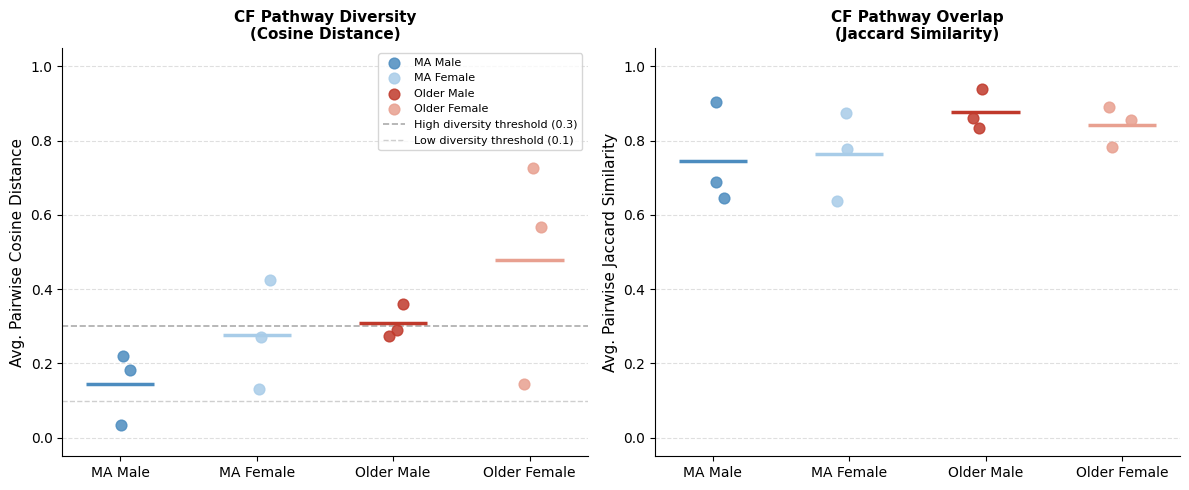

In [2]:
# %%
# ## 8. CF Pathway Diversity Quantification
# Measures structural diversity among the four recourse candidates
# generated per patient using pairwise cosine distance and Jaccard
# similarity on the set of changed variables.
#
# Metrics per case:
#   - Avg. pairwise cosine distance  : captures magnitude-weighted diversity
#   - Avg. Jaccard similarity        : captures overlap in changed variable sets
#   - Structural diversity label     : High / Medium / Low
#
# A structurally diverse recourse menu allows policyholders to choose
# a pathway matched to their capacity and preference, which is the
# key practical claim of the DiCE diversity objective.

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.preprocessing import StandardScaler

SAVE_FIG_KWARGS = dict(dpi=600, bbox_inches='tight', facecolor='white')

def save_fig(fig, name: str):
    for ext in ['png', 'pdf', 'tiff']:
        fig.savefig(f'../results/figures/{name}.{ext}',
                    format=ext, **SAVE_FIG_KWARGS)
    print(f"  Saved: {name} (PNG/PDF/TIFF 600 dpi)")

# Load counterfactual results
with open('../results/tables/counterfactuals.json', 'r', encoding='utf-8') as f:
    cf_data = json.load(f)

NUMERIC_VARS = [
    'BMI', 'WaistCirc', 'Weight',
    'Energy_kcal', 'Carb_g', 'Sugar_g', 'Sodium_mg',
    'Fat_g', 'Protein_g', 'Potassium_mg', 'Fiber_g', 'SaturatedFat_g',
]

TOL_PCT = 1.0   # threshold: >1% change counts as "modified"

def cosine_distance(v1: np.ndarray, v2: np.ndarray) -> float:
    """
    1 - cosine_similarity between two delta vectors.
    Returns 0 if either vector is zero (identical pathways).
    """
    norm1, norm2 = np.linalg.norm(v1), np.linalg.norm(v2)
    if norm1 == 0 or norm2 == 0:
        return 0.0
    return 1.0 - float(np.dot(v1, v2) / (norm1 * norm2))


def jaccard_similarity(set1: set, set2: set) -> float:
    """
    Jaccard similarity between two sets of changed variable names.
    Returns 1.0 if both sets are empty (no changes — identical null pathways).
    """
    if not set1 and not set2:
        return 1.0
    intersection = len(set1 & set2)
    union        = len(set1 | set2)
    return intersection / union if union > 0 else 1.0


diversity_records = []

for result in cf_data['results']:
    if result['status'] != 'success':
        continue

    case_key = result['case_key']
    group    = result['group']
    orig     = result['original']
    cfs      = result['counterfactuals']

    if len(cfs) < 2:
        continue   # Need at least 2 CFs for pairwise comparison

    # Build delta vectors (CF value - original value) for numeric variables
    delta_vecs  = []
    changed_sets = []

    for cf in cfs:
        delta = []
        changed = set()
        for var in NUMERIC_VARS:
            o = float(orig.get(var, 0))
            c = float(cf.get(var,  o))
            d = c - o
            delta.append(d)
            if o != 0 and abs(d / o) * 100 > TOL_PCT:
                changed.add(var)
        delta_vecs.append(np.array(delta))
        changed_sets.append(changed)

    # Pairwise cosine distances
    cos_dists = [
        cosine_distance(delta_vecs[i], delta_vecs[j])
        for i, j in combinations(range(len(cfs)), 2)
    ]

    # Pairwise Jaccard similarities
    jac_sims = [
        jaccard_similarity(changed_sets[i], changed_sets[j])
        for i, j in combinations(range(len(cfs)), 2)
    ]

    avg_cos  = np.mean(cos_dists)
    avg_jac  = np.mean(jac_sims)

    # Structural diversity label
    # High   : avg cosine distance > 0.3 (pathways substantially differ)
    # Medium : 0.1 < avg cosine distance <= 0.3
    # Low    : avg cosine distance <= 0.1 (pathways are near-identical)
    if avg_cos > 0.3:
        div_label = 'High'
    elif avg_cos > 0.1:
        div_label = 'Medium'
    else:
        div_label = 'Low'

    diversity_records.append({
        'CaseKey':          case_key,
        'Group':            group,
        'N_CFs':            len(cfs),
        'Avg_CosDist':      round(avg_cos, 4),
        'Avg_JaccardSim':   round(avg_jac, 4),
        'DiversityLabel':   div_label,
    })

diversity_df = pd.DataFrame(diversity_records)
diversity_df.to_csv('../results/tables/cf_diversity.csv',
                    index=False, encoding='utf-8-sig')

print("CF Pathway Diversity Summary:")
print(diversity_df[['CaseKey', 'Avg_CosDist',
                     'Avg_JaccardSim', 'DiversityLabel']].to_string(index=False))

print("\nGroup-level mean cosine distance:")
print(diversity_df.groupby('Group')['Avg_CosDist'].agg(['mean', 'std']).round(4))

print("\nDiversity label distribution:")
print(diversity_df['DiversityLabel'].value_counts())
print(">>> Saved: ../results/tables/cf_diversity.csv")

# %%
# ## 9. CF Diversity Figure

GROUPS   = ['MiddleAged_Male', 'MiddleAged_Female',
            'Older_Male',      'Older_Female']
G_LABELS = ['MA Male', 'MA Female', 'Older Male', 'Older Female']
COLORS   = ['#4C8CBF', '#A8CCE8', '#C0392B', '#E8A090']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: Avg cosine distance by group (scatter with mean line)
ax = axes[0]
for i, (g, gl, col) in enumerate(zip(GROUPS, G_LABELS, COLORS)):
    sub  = diversity_df[diversity_df['Group'] == g]['Avg_CosDist'].values
    x    = np.full(len(sub), i) + np.random.uniform(-0.1, 0.1, len(sub))
    ax.scatter(x, sub, color=col, s=60, zorder=3, label=gl, alpha=0.85)
    ax.hlines(sub.mean(), i - 0.25, i + 0.25,
              colors=col, linewidths=2.5, zorder=4)

ax.axhline(0.3, color='#888888', linestyle='--', lw=1.2, alpha=0.7,
           label='High diversity threshold (0.3)')
ax.axhline(0.1, color='#bbbbbb', linestyle='--', lw=1.0, alpha=0.7,
           label='Low diversity threshold (0.1)')

ax.set_xticks(range(len(GROUPS)))
ax.set_xticklabels(G_LABELS, fontsize=10)
ax.set_ylabel('Avg. Pairwise Cosine Distance', fontsize=11)
ax.set_ylim(-0.05, 1.05)
ax.set_title('CF Pathway Diversity\n(Cosine Distance)',
             fontsize=11, fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=8, loc='upper right')

# Panel 2: Avg Jaccard similarity by group
ax = axes[1]
for i, (g, gl, col) in enumerate(zip(GROUPS, G_LABELS, COLORS)):
    sub = diversity_df[diversity_df['Group'] == g]['Avg_JaccardSim'].values
    x   = np.full(len(sub), i) + np.random.uniform(-0.1, 0.1, len(sub))
    ax.scatter(x, sub, color=col, s=60, zorder=3, alpha=0.85)
    ax.hlines(sub.mean(), i - 0.25, i + 0.25,
              colors=col, linewidths=2.5, zorder=4)

ax.set_xticks(range(len(GROUPS)))
ax.set_xticklabels(G_LABELS, fontsize=10)
ax.set_ylabel('Avg. Pairwise Jaccard Similarity', fontsize=11)
ax.set_ylim(-0.05, 1.05)
ax.set_title('CF Pathway Overlap\n(Jaccard Similarity)',
             fontsize=11, fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
save_fig(fig, 'figure_cf_diversity')
plt.show()